In [10]:
import spectral as spy
import spectral.io.envi as envi
import numpy as np 

import scipy.ndimage as ndimage
img = envi.open(r"C:\Users\shash\OneDrive - purdue.edu\Summer\hsi\sio2\sio2 all 20 dish white.bil.hdr")
cube = img.load()
bare_si_cube = spy.open_image(r"C:\Users\shash\OneDrive - purdue.edu\Summer\hsi\sio2\bare silicon large square.bip.hdr").load()

bare_si_ref = np.mean(bare_si_cube, axis=(0, 1))

data_cube = cube
raw_intensity = np.mean(data_cube, axis=2)

# Create a smooth estimate of the lighting gradient (heavy Gaussian blur)
# Adjust sigma based on image dimensions (e.g., 10% to 20% of image width)
lighting_gradient = ndimage.gaussian_filter(raw_intensity, sigma=50)

# Normalize/Flat-field correct the data cube pixel-by-pixel
# Flattening lighting prevents the right side from appearing artificially dark
flat_cube = data_cube / (lighting_gradient[:, :, np.newaxis] + 1e-6)

# Flat-corrected intensity map
flat_intensity = np.mean(flat_cube, axis=2)


C:\Users\shash\AppData\Local\Temp\ipykernel_36088\2828728587.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  flat_cube = data_cube / (lighting_gradient[:, :, np.newaxis] + 1e-6)


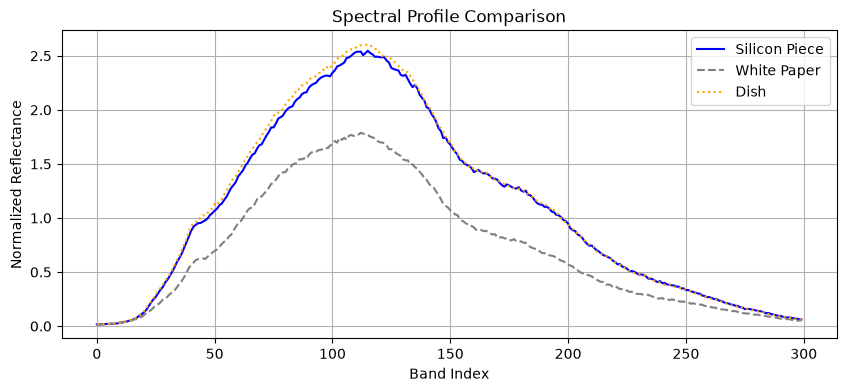

In [11]:
# Plot average spectrum from 3 sample coordinates:
# (Replace r, c with actual row/col coordinates in your image)
silicon_spec = flat_cube[150, 150, :] # On a silicon piece
paper_spec   = flat_cube[50, 300, :]  # On the white paper
dish_spec    = flat_cube[200, 100, :] # On the transparent dish

plt.figure(figsize=(10, 4))
plt.plot(silicon_spec, label='Silicon Piece', color='blue')
plt.plot(paper_spec, label='White Paper', color='gray', linestyle='--')
plt.plot(dish_spec, label='Dish', color='orange', linestyle=':')
plt.xlabel('Band Index')
plt.ylabel('Normalized Reflectance')
plt.legend()
plt.title('Spectral Profile Comparison')
plt.grid(True)
plt.show()

In [16]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import spectral.io.envi as envi
%matplotlib inline
# 1. Load Data Cube (Rows, Cols, Bands)
data_cube = flat_cube
rows, cols, bands = data_cube.shape

mean_intensity = np.mean(data_cube, axis=2)

# 2. Compute a Spatial Energy / Variance Map
# Wafer pieces usually have distinct total reflectivity / variance compared to paper/dish
intensity_map = np.mean(data_cube, axis=2)
variance_map = np.std(data_cube, axis=2)

# 3. Create initial foreground mask (Adjust threshold to separate background)
# Paper/glass usually have flatter or higher reflectance spectra
background_threshold = np.percentile(variance_map, 50) 
foreground_mask = variance_map > background_threshold

# 4. Cleanup Mask using Morphological Operations (fill holes, remove tiny noise)
foreground_mask = ndimage.binary_fill_holes(foreground_mask)
foreground_mask = ndimage.binary_opening(foreground_mask, structure=np.ones((5,5)))

# 5. Label distinct pieces on the dish
labeled_pieces, num_pieces = ndimage.label(foreground_mask)
print(f"Detected {num_pieces} distinct sample pieces on the dish.")

Detected 206 distinct sample pieces on the dish.


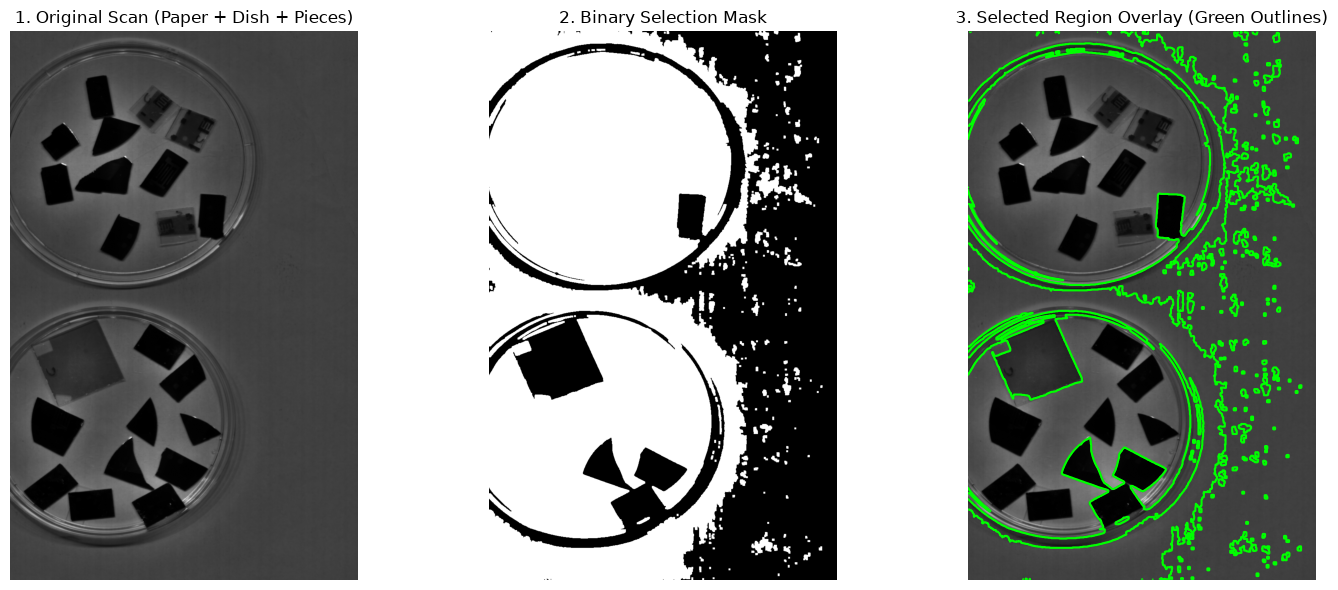

In [17]:
isolated_pieces = mean_intensity.copy()
isolated_pieces[~foreground_mask] = np.nan  # Mask background out

# Create RGB False-Color / Intensity image with Green Contours around selected pieces
plt.figure(figsize=(15, 6))

# Plot 1: Original Mean Intensity Image
plt.subplot(1, 3, 1)
plt.imshow(mean_intensity, cmap='gray')
plt.title('1. Original Scan (Paper + Dish + Pieces)')
plt.axis('off')

# Plot 2: Binary Selection Mask (White = Selected Wafer Pieces)
plt.subplot(1, 3, 2)
plt.imshow(foreground_mask, cmap='gray')
plt.title('2. Binary Selection Mask')
plt.axis('off')

# Plot 3: Overlay — Green Outlines on Original Image
plt.subplot(1, 3, 3)
plt.imshow(mean_intensity, cmap='gray')
# Overlay contour lines corresponding to the mask boundary
plt.contour(foreground_mask, colors='lime', linewidths=1.5)
plt.title('3. Selected Region Overlay (Green Outlines)')
plt.axis('off')

plt.tight_layout()

In [7]:
from scipy.spatial.distance import cosine

# Mean reference spectrum of pure Si (from your reference raw silicon image)
pure_si_ref = np.mean(bare_si_cube, axis=(0, 1))

# Initialize output map (0 = Background, 1 = Pure Si, 2 = SiO2 layer)
material_map = np.zeros((rows, cols), dtype=int)

# Loop over each foreground pixel inside the masked pieces
for r in range(rows):
    for c in range(cols):
        if foreground_mask[r, c]:  # Only process actual film pixels
            pixel_spectrum = data_cube[r, c, :]
            
            # Compute Spectral Angle / Cosine Distance against Pure Si reference
            # Angular distance = acos(1 - cosine_distance)
            cos_dist = cosine(pixel_spectrum, pure_si_ref)
            spectral_angle = np.arccos(np.clip(1 - cos_dist, -1.0, 1.0))
            
            # Angle near 0 means Pure Si; higher angle indicates SiO2 oxide presence
            if spectral_angle < 0.08:  # Adjust threshold based on your signal
                material_map[r, c] = 1  # Silicon (Si)
            else:
                material_map[r, c] = 2  # Silicon Dioxide (SiO2)

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(foreground_mask, cmap='gray')
plt.title('Isolated Film Pieces (Background Masked Out)')

plt.subplot(1, 2, 2)
# Custom colormap: 0 = Dark (Background), 1 = Blue (Si), 2 = Red (SiO2)
plt.imshow(material_map, cmap='jet')
plt.title('Material Map: Blue = Si, Red = SiO2')
plt.colorbar(ticks=[0, 1, 2], label='0: Background, 1: Si, 2: SiO2')
plt.show()

ValueError: Input vector should be 1-D.